MODEL 2

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import sklearn.pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv('E:/OneDrive/Documents/coding/MLInternship/week2/Titanic-Dataset.csv')

In [3]:
df['hascabin'] = df['Cabin'].notna().astype(int)

In [4]:
df['Age'].fillna(df['Age'].median(), inplace=True)


C:\Users\mabdu\AppData\Local\Temp\ipykernel_20824\286566303.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [5]:
df = df.drop('Name',axis =1)
df = df.drop('ivPassengerId',axis =1)

In [6]:
cabin_encoder = LabelEncoder()
df['Cabin'] = cabin_encoder.fit_transform(df['Cabin'])

In [7]:
sex_encoder = LabelEncoder()
df['Sex'] = sex_encoder.fit_transform(df['Sex'])

In [8]:
df = df.drop('Ticket',axis =1)

In [9]:
embarked_encoder = LabelEncoder()
df['Embarked'] = embarked_encoder.fit_transform(df['Embarked'])

In [10]:
df['cabin_deck'] = df['Cabin'].fillna('U').astype(str).str[0]


In [11]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,hascabin,cabin_deck
0,0,3,1,22.0,1,0,7.2500,147,2,0,1
1,1,1,0,38.0,1,0,71.2833,81,0,1,8
2,1,3,0,26.0,0,0,7.9250,147,2,0,1
3,1,1,0,35.0,1,0,53.1000,55,2,1,5
4,0,3,1,35.0,0,0,8.0500,147,2,0,1


In [12]:
survivedbycabin = df.groupby('hascabin')['Survived'].mean()
print("Survival rate by cabin presence (0 = No Cabin, 1 = Has Cabin):")
print(survivedbycabin)


# Survival rate for each cabin deck
if 'cabin_deck' in df.columns:
    survivedbydeck = df.groupby('cabin_deck')['Survived'].mean().sort_index()
    print("\nSurvival rate by cabin deck:")
    print(survivedbydeck)
else:
    print("Column 'cabin_deck' not found in DataFrame.")

Survival rate by cabin presence (0 = No Cabin, 1 = Has Cabin):
hascabin
0    0.299854
1    0.666667
Name: Survived, dtype: float64

Survival rate by cabin deck:
cabin_deck
0    0.000000
1    0.338542
2    0.714286
3    0.750000
4    0.800000
5    0.533333
6    0.470588
7    0.733333
8    0.642857
9    0.750000
Name: Survived, dtype: float64


C:\Users\mabdu\AppData\Local\Temp\ipykernel_20824\1306727603.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='hascabin', y='Survived', data=df, ci=None, palette='pastel')
C:\Users\mabdu\AppData\Local\Temp\ipykernel_20824\1306727603.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='hascabin', y='Survived', data=df, ci=None, palette='pastel')


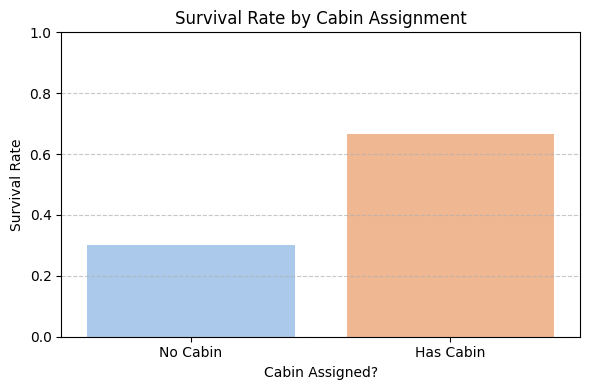

C:\Users\mabdu\AppData\Local\Temp\ipykernel_20824\1306727603.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='cabin_deck', y='Survived', data=df, ci=None, order=sorted(df['cabin_deck'].unique()), palette='muted')
C:\Users\mabdu\AppData\Local\Temp\ipykernel_20824\1306727603.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cabin_deck', y='Survived', data=df, ci=None, order=sorted(df['cabin_deck'].unique()), palette='muted')


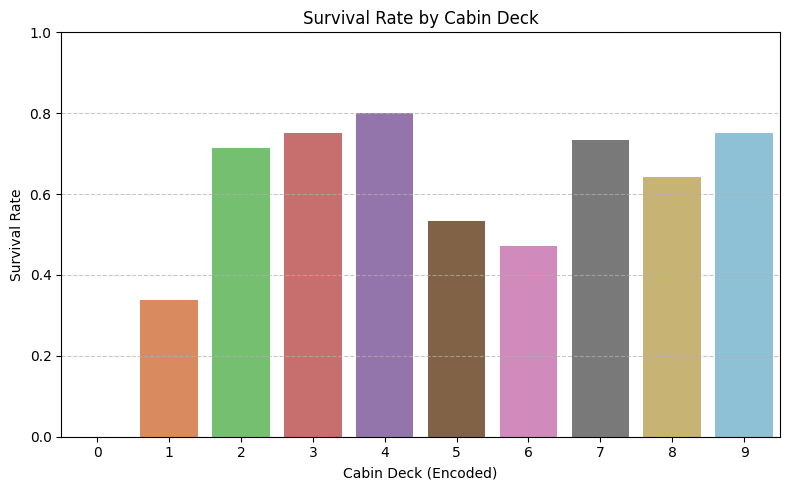

In [13]:
plt.figure(figsize=(6, 4))
sns.barplot(x='hascabin', y='Survived', data=df, ci=None, palette='pastel')

plt.xticks([0, 1], ['No Cabin', 'Has Cabin'])
plt.title("Survival Rate by Cabin Assignment")
plt.ylabel("Survival Rate")
plt.xlabel("Cabin Assigned?")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x='cabin_deck', y='Survived', data=df, ci=None, order=sorted(df['cabin_deck'].unique()), palette='muted')

plt.title("Survival Rate by Cabin Deck")
plt.ylabel("Survival Rate")
plt.xlabel("Cabin Deck (Encoded)")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [14]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['Alone'] = (df['FamilySize'] == 1).astype(int)



In [15]:
df.groupby('FamilySize')['Survived'].mean()


FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

In [16]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,hascabin,cabin_deck,FamilySize,Alone
0,0,3,1,22.0,1,0,7.2500,147,2,0,1,2,0
1,1,1,0,38.0,1,0,71.2833,81,0,1,8,2,0
2,1,3,0,26.0,0,0,7.9250,147,2,0,1,1,1
3,1,1,0,35.0,1,0,53.1000,55,2,1,5,2,0
4,0,3,1,35.0,0,0,8.0500,147,2,0,1,1,1


In [17]:

# Remove outliers from numeric columns using the IQR method
numeric_cols = df.select_dtypes(include=[np.number]).columns
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Keep only rows where all numeric columns are within 1.5*IQR
# This creates a new DataFrame without outliers

df_no_outliers = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

print(f"Original shape: {df.shape}")
print(f"Shape after removing outliers: {df_no_outliers.shape}")

df = df_no_outliers



Original shape: (891, 13)
Shape after removing outliers: (499, 13)


In [18]:
x = df.drop(['Survived'], axis =1)
y = df['Survived']
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

print (x)

     Pclass  Sex   Age  SibSp  Parch     Fare  Cabin  Embarked  hascabin  \
0         3    1  22.0      1      0   7.2500    147         2         0   
2         3    0  26.0      0      0   7.9250    147         2         0   
4         3    1  35.0      0      0   8.0500    147         2         0   
5         3    1  28.0      0      0   8.4583    147         1         0   
9         2    0  14.0      1      0  30.0708    147         0         0   
..      ...  ...   ...    ...    ...      ...    ...       ...       ...   
882       3    0  22.0      0      0  10.5167    147         2         0   
883       2    1  28.0      0      0  10.5000    147         2         0   
884       3    1  25.0      0      0   7.0500    147         2         0   
886       2    1  27.0      0      0  13.0000    147         2         0   
890       3    1  32.0      0      0   7.7500    147         1         0   

    cabin_deck  FamilySize  Alone  
0            1           2      0  
2            1 

In [19]:
pipelines = {
    'DecisionTree' : Pipeline([
        ('scalar', StandardScaler()),
        ('clf', DecisionTreeClassifier(max_depth=1, random_state=42))

    ]),
    'KNN': Pipeline([
        ('scalar', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=17))
    ]),
    'Naive-Bayes': Pipeline([
        ('scalar', StandardScaler()),
        ('clf', GaussianNB())

        ])
}


In [20]:
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

In [21]:
k_range = range(1, 21)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    pipeline = Pipeline([
        ('scalar', StandardScaler()),
        ('clf', knn)
    ])
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    scores.append(score)
    print(f"K={k}: Test Accuracy = {score:.4f}")

best_k = k_range[scores.index(max(scores))]
print(f"Best K: {best_k} with accuracy {max(scores):.4f}")

K=1: Test Accuracy = 0.7400
K=2: Test Accuracy = 0.8000
K=3: Test Accuracy = 0.7900
K=4: Test Accuracy = 0.8500
K=5: Test Accuracy = 0.8500
K=6: Test Accuracy = 0.8500
K=7: Test Accuracy = 0.8400
K=8: Test Accuracy = 0.8200
K=9: Test Accuracy = 0.8100
K=10: Test Accuracy = 0.8200
K=11: Test Accuracy = 0.8100
K=12: Test Accuracy = 0.8000
K=13: Test Accuracy = 0.7700
K=14: Test Accuracy = 0.7800
K=15: Test Accuracy = 0.7900
K=16: Test Accuracy = 0.8200
K=17: Test Accuracy = 0.8100
K=18: Test Accuracy = 0.8100
K=19: Test Accuracy = 0.8100
K=20: Test Accuracy = 0.8200
Best K: 4 with accuracy 0.8500


In [22]:
from sklearn.model_selection import GridSearchCV

# Set up parameter grid for max_depth
param_grid = {'clf__max_depth': range(1, 21)}

dt_pipeline = Pipeline([
    ('scalar', StandardScaler()),
    ('clf', DecisionTreeClassifier(random_state=42))
])

grid_search = GridSearchCV(dt_pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print(f"Best max_depth: {grid_search.best_params_['clf__max_depth']}")
print(f"Best cross-validated accuracy: {grid_search.best_score_:.4f}")

# Evaluate on test set
best_dt = grid_search.best_estimator_
test_acc = best_dt.score(X_test, y_test)
print(f"Test set accuracy with best max_depth: {test_acc:.4f}")

Best max_depth: 1
Best cross-validated accuracy: 0.8322
Test set accuracy with best max_depth: 0.8200


In [23]:
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    train_score = pipe.score(X_train, y_train)
    test_score = pipe.score(X_test, y_test)
    print(f"{name} training accuracy: {train_score:.4f}")
    print(f"{name} testing accuracy: {test_score:.4f}")
    print("-" * 30)

DecisionTree training accuracy: 0.8321
DecisionTree testing accuracy: 0.8200
------------------------------
KNN training accuracy: 0.8446
KNN testing accuracy: 0.8100
------------------------------
Naive-Bayes training accuracy: 0.8170
Naive-Bayes testing accuracy: 0.7800
------------------------------



DecisionTree Model Evaluation


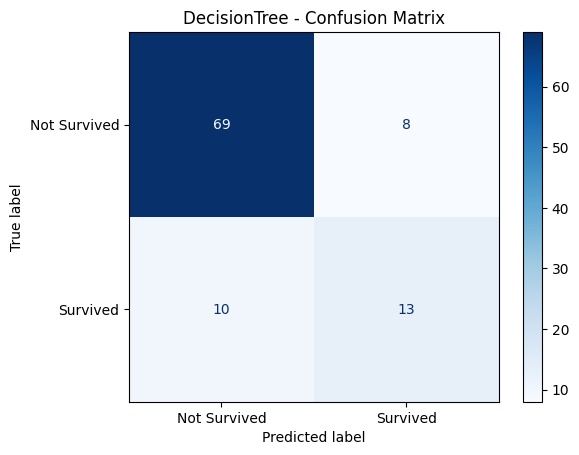

              precision    recall  f1-score   support

Not Survived       0.87      0.90      0.88        77
    Survived       0.62      0.57      0.59        23

    accuracy                           0.82       100
   macro avg       0.75      0.73      0.74       100
weighted avg       0.81      0.82      0.82       100



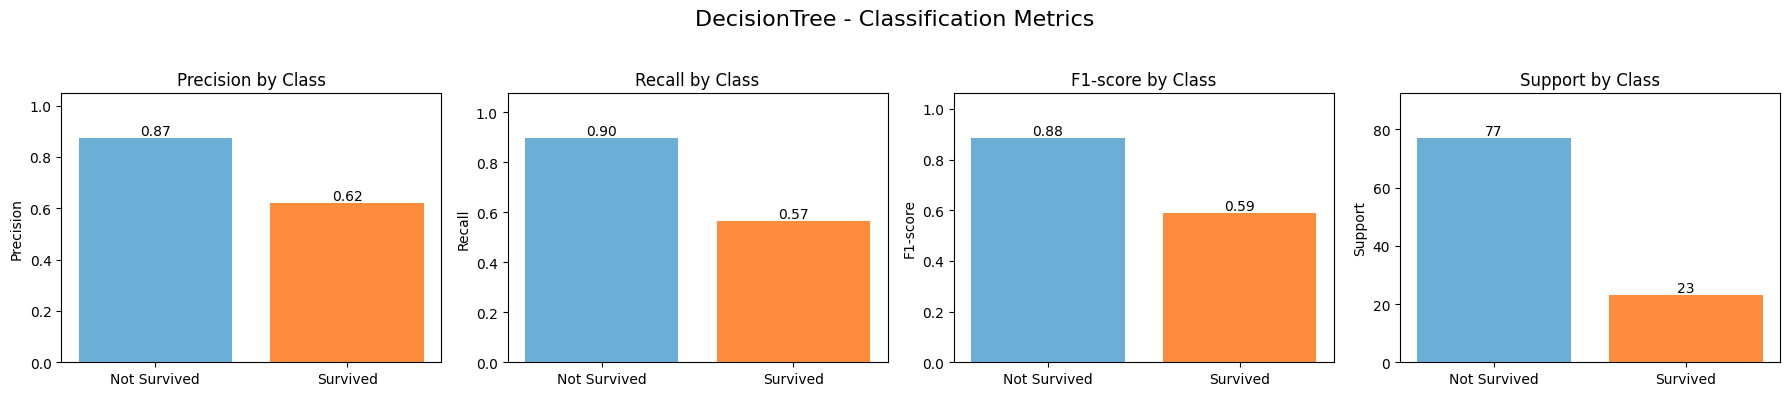


KNN Model Evaluation


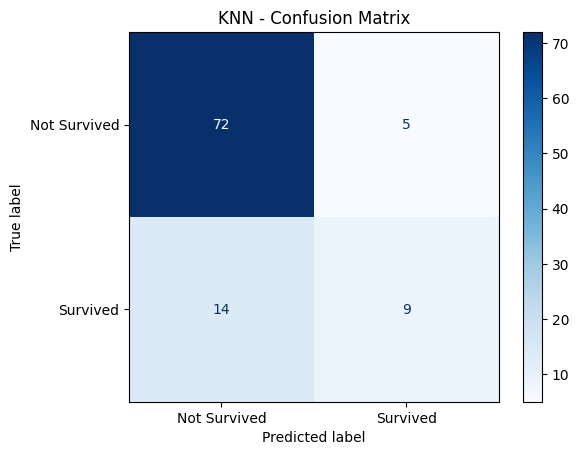

              precision    recall  f1-score   support

Not Survived       0.84      0.94      0.88        77
    Survived       0.64      0.39      0.49        23

    accuracy                           0.81       100
   macro avg       0.74      0.66      0.68       100
weighted avg       0.79      0.81      0.79       100



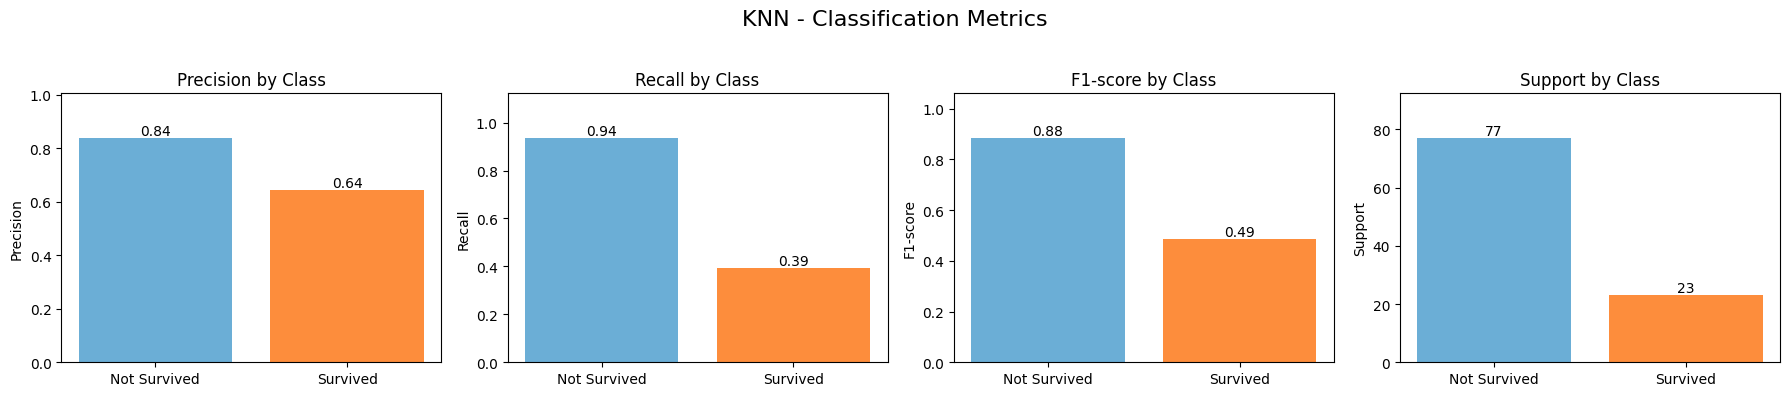


Naive-Bayes Model Evaluation


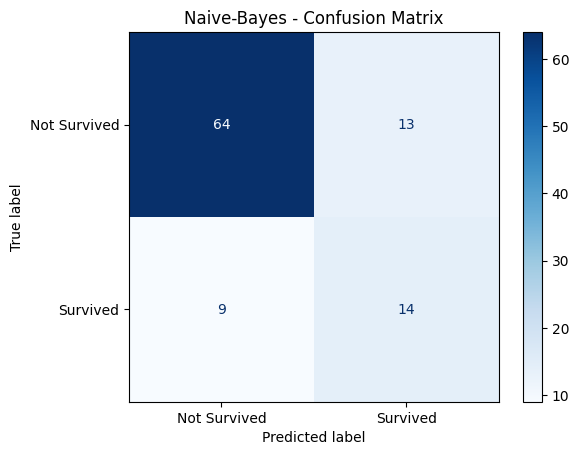

              precision    recall  f1-score   support

Not Survived       0.88      0.83      0.85        77
    Survived       0.52      0.61      0.56        23

    accuracy                           0.78       100
   macro avg       0.70      0.72      0.71       100
weighted avg       0.79      0.78      0.79       100



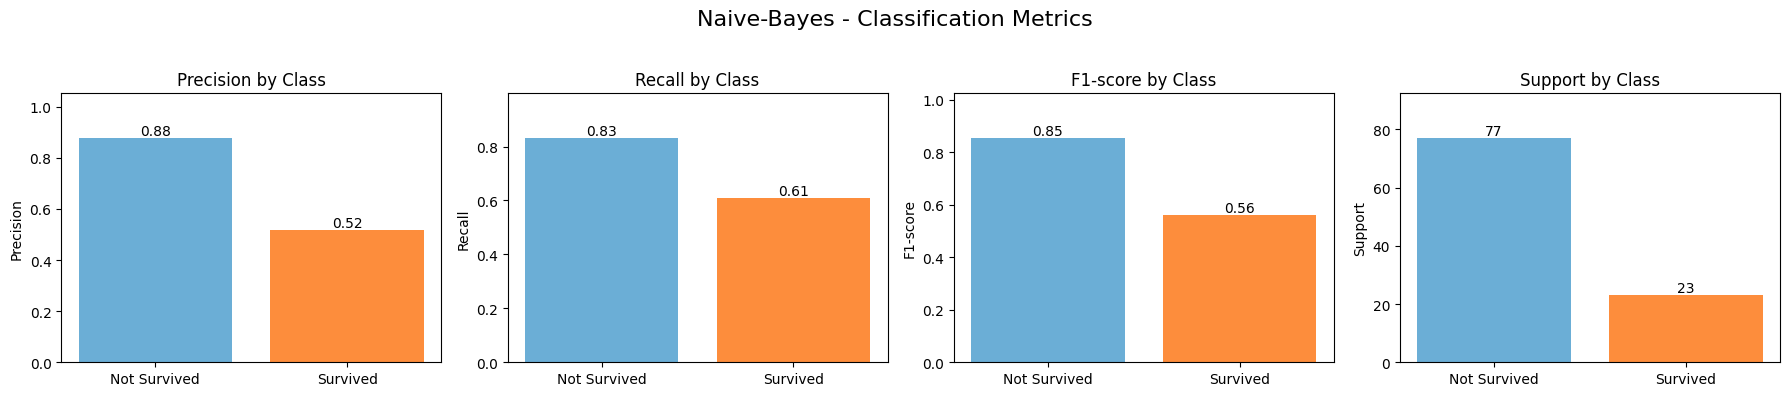

In [24]:
model_names = ['DecisionTree', 'KNN', 'Naive-Bayes']

for name in model_names:
    print(f"\n{name} Model Evaluation")
    y_pred = pipelines[name].predict(X_test)
    
    # Confusion Matrix
    disp = ConfusionMatrixDisplay.from_estimator(
        pipelines[name], X_test, y_test, cmap='Blues', display_labels=['Not Survived', 'Survived']
    )
    disp.ax_.set_title(f"{name} - Confusion Matrix")
    plt.show()
    
    # Classification Report
    report = classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived'], output_dict=True)
    print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))
    
    # Extract metrics
    metrics = ['precision', 'recall', 'f1-score', 'support']
    classes = ['Not Survived', 'Survived']
    values = {metric: [report[cls][metric] for cls in classes] for metric in metrics}
    
    # Plot metrics
    fig, axs = plt.subplots(1, 4, figsize=(18, 4))
    for i, metric in enumerate(metrics):
        axs[i].bar(classes, values[metric], color=['#6baed6', '#fd8d3c'])
        axs[i].set_title(f"{metric.capitalize()} by Class")
        axs[i].set_ylabel(metric.capitalize())
        axs[i].set_ylim(0, max(values[metric]) * 1.2 if metric != 'support' else max(values[metric]) * 1.2)
        for idx, val in enumerate(values[metric]):
            axs[i].text(idx, val, f"{val:.2f}" if metric != 'support' else f"{int(val)}", ha='center', va='bottom')
    fig.suptitle(f"{name} - Classification Metrics", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()